# Climate Statistics Pipeline — ERA5 over Illinois

Single wrapper notebook for the full pipeline:

```
Step 1: Extract ERA5 data (with local caching)
Step 2: Compute derived heat metrics
Step 3: Compute summary statistics (daily + averages)
Step 4: Aggregate to county level
Step 5: Save output CSVs
Step 6: Visualize results
```

Edit the **Parameters** cell below to configure which metrics, time range, and thresholds to use.

---
## Parameters

In [31]:
import os

# ═══ PARAMETERS 1═══════════════════════════════════════════════════════════
# ── Data directory — edit this one path if your data lives elsewhere ──────
DATA_DIR = "data"

# ── Time range (inclusive) ────────────────────────────────────────────────
YEAR_START = 2020
YEAR_END   = 2026

# ── Metrics to compute (any subset of the registry) ──────────────────────
#   "heat_index", "wet_bulb_temperature", "apparent_temperature",
#   "humidex", "normal_effective_temperature", "wind_chill", "wbgt"
METRICS = ["heat_index",
        "wet_bulb_temperature",
        "apparent_temperature",
        "humidex",
        "normal_effective_temperature",
        "wind_chill",
        "wbgt"]

# ── Thresholds for exceedance statistics ──────────────────────────────────
# Units must match metric output (°F when CONVERT_TO_F=True, else K).
# Use "above" for heat metrics and "below" for cold metrics (wind chill).
THRESHOLDS = {
    "heat_index":                   {"above": [90, 104]},   # NWS: 90 = extreme caution, 104 = danger
    "wet_bulb_temperature":         {"above": [75, 80]},    # 75 = uncomfortable, 80 = dangerous
    "apparent_temperature":         {"above": [90, 105]},   # similar scale to heat index
    "humidex":                      {"above": [90, 104]},   # 90 = some discomfort, 104 = great discomfort
    "normal_effective_temperature": {"above": [70, 80]},    # 70 = warm discomfort, 80 = hot stress
    "wind_chill":                   {"below": [-25,-15,0, 32]},     # 32 = frostbite risk, 0 = high danger
    "wbgt":                         {"above": [80, 85]},    # occupational: 80 = caution, 85 = warning
}

# ── Unit conversion ───────────────────────────────────────────────────────
# If True, metrics natively in Kelvin are converted to °F before statistics
CONVERT_TO_F = True

# ── Derived paths (do not edit unless you have a custom directory layout) ─
CACHE_DIR  = os.path.join(DATA_DIR, "cache")
OUTPUT_DIR     = os.path.join(DATA_DIR, "output")
SHAPEFILE_PATH = os.path.join(DATA_DIR, "shapefiles", "county", "tl_2025_us_county.shp")

---
## Imports

In [32]:
import xarray as xr
import pandas as pd

from climstat.era5_extract import extract_era5
from climstat.metrics import compute_metrics, METRIC_REGISTRY
from climstat.statistics import daily_summary, averages_summary
from climstat.county_agg import aggregate_to_counties
from climstat.visualization import (
    plot_county_timeseries,
    plot_county_map,
    plot_threshold_heatmap,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Threshold helpers ─────────────────────────────────────────────────────
# Extract "above" and "below" threshold lists from the THRESHOLDS dict.
# Metrics without an entry get empty lists for both.

def _get_thresholds(name: str) -> tuple[list, list]:
    """Return (thresholds_above, thresholds_below) for a metric."""
    entry = THRESHOLDS.get(name, {})
    return entry.get("above", []), entry.get("below", [])

---
## Step 1 — Extract ERA5 Data

Downloads from Google Cloud ARCO-ERA5 and caches locally as NetCDF.  
Subsequent runs with the same parameters load from cache.

In [33]:
# Determine which ERA5 variables are needed for the requested metrics
needed_vars = set()
for m in METRICS:
    needed_vars.update(METRIC_REGISTRY[m]["era5_vars"])
needed_vars = sorted(needed_vars)
print(f"ERA5 variables needed: {needed_vars}")

# Check which variables still need downloading vs. already cached
years = list(range(YEAR_START, YEAR_END + 1))
from climstat.era5_extract import _find_cached
not_cached = sorted({
    var for var in needed_vars
    if any(_find_cached(CACHE_DIR, var, yr) is None for yr in years)
})
cached_vars = sorted(set(needed_vars) - set(not_cached))
if cached_vars:
    print(f"ERA5 variables already cached: {cached_vars}")
print(f"ERA5 variables to download: {not_cached if not_cached else '(none)'}")

ds = extract_era5(
    variables=needed_vars,
    year_start=YEAR_START,
    year_end=YEAR_END,
    cache_dir=CACHE_DIR,
)
print(ds)

ERA5 variables needed: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_dewpoint_temperature', '2m_temperature']
ERA5 variables already cached: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_dewpoint_temperature', '2m_temperature']
ERA5 variables to download: (none)
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20200101_20201231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20210101_20211231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20220101_20221231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20230101_20231231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20240101_20241231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20250101_20251231.nc
[era5_extract] Cache hit: era5_10m_u_component_of_wind_20260101_20260326.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20200101_20201231.nc
[era5_extract] Cache hit: era5_10m_v_component_of_wind_20210101_20211231.nc
[era5_extract] Cache hit: e

/Users/cristi/Desktop/claude/climstat-era5/climstat/era5_extract.py:399: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  merged = xr.merge(var_datasets)
/Users/cristi/Desktop/claude/climstat-era5/climstat/era5_extract.py:399: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  merged = xr.merge(var_datasets)


[era5_extract] Done. Dataset spans 2020-01-01 -> 2026-03-26
<xarray.Dataset> Size: 441MB
Dimensions:                  (lat: 24, lon: 21, time: 54648)
Coordinates:
  * lat                      (lat) float32 96B 37.0 37.25 37.5 ... 42.5 42.75
  * lon                      (lon) float32 84B 268.2 268.5 268.8 ... 273.0 273.2
  * time                     (time) datetime64[ns] 437kB 2020-01-01 ... 2026-...
Data variables:
    10m_u_component_of_wind  (time, lat, lon) float32 110MB 3.894 3.837 ... nan
    10m_v_component_of_wind  (time, lat, lon) float32 110MB 0.4833 0.633 ... nan
    2m_dewpoint_temperature  (time, lat, lon) float32 110MB nan nan ... nan nan
    2m_temperature           (time, lat, lon) float32 110MB nan nan ... nan nan
Attributes:
    last_updated:           2026-03-26 10:52:13.759322+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-03-20


---
## Step 2 — Compute Derived Metrics

In [34]:
print("Computing derived metrics ...")
metric_arrays = compute_metrics(ds, metric_names=METRICS, convert_to_fahrenheit=CONVERT_TO_F)

# Free raw ERA5 data from memory
del ds

for name, arr in metric_arrays.items():
    print(f"  {name}: shape={arr.shape}, min={float(arr.min()):.1f}, max={float(arr.max()):.1f}")

Computing derived metrics ...
[metrics] Computing heat_index ...


/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


[metrics] Computing wet_bulb_temperature ...
[metrics] Computing apparent_temperature ...
[metrics] Computing humidex ...
[metrics] Computing normal_effective_temperature ...
[metrics] Computing wind_chill ...
[metrics] Computing wbgt ...
  heat_index: shape=(54648, 24, 21), min=-32.5, max=132.5
  wet_bulb_temperature: shape=(54648, 24, 21), min=-24.8, max=89.5
  apparent_temperature: shape=(54648, 24, 21), min=-36.1, max=112.9
  humidex: shape=(54648, 24, 21), min=-33.6, max=128.9
  normal_effective_temperature: shape=(54648, 24, 21), min=-65.5, max=91.4
  wind_chill: shape=(54648, 24, 21), min=-45.6, max=49.7
  wbgt: shape=(54648, 24, 21), min=-24.6, max=90.6


---
## Step 3 — Compute Summary Statistics

In [35]:
daily_results = {}    # metric_name -> xr.Dataset (daily time series, gridded)
averages_results = {} # metric_name -> xr.Dataset (climatological, gridded)

for name, arr in metric_arrays.items():
    above, below = _get_thresholds(name)
    print(f"\n--- {name} (above: {above}, below: {below}) ---")

    print("  Computing daily summary ...")
    daily_results[name] = daily_summary(arr, thresholds=above, thresholds_below=below)

    print("  Computing averages summary ...")
    averages_results[name] = averages_summary(arr, thresholds=above, thresholds_below=below)

print("\nDone.")


--- heat_index (above: [90, 104], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

--- wet_bulb_temperature (above: [75, 80], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

--- apparent_temperature (above: [90, 105], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

--- humidex (above: [90, 104], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

--- normal_effective_temperature (above: [70, 80], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

--- wind_chill (above: [], below: [-25, -15, 0, 32]) ---
  Computing daily summary ...
  Computing averages summary ...

--- wbgt (above: [80, 85], below: []) ---
  Computing daily summary ...
  Computing averages summary ...

Done.


---
## Step 4 — Aggregate to County Level

In [36]:
daily_county = {}     # metric_name -> pd.DataFrame
averages_county = {}  # metric_name -> pd.DataFrame

for name in METRICS:
    print(f"\n=== {name} ===")

    print("  Aggregating daily summary to counties ...")
    daily_county[name] = aggregate_to_counties(
        daily_results[name], shapefile_path=SHAPEFILE_PATH
    )

    print("  Aggregating averages to counties ...")
    averages_county[name] = aggregate_to_counties(
        averages_results[name], shapefile_path=SHAPEFILE_PATH
    )

print("\nDone.")


=== heat_index ===
  Aggregating daily summary to counties ...
[county_agg] Loading Illinois county shapefile ...
[county_agg] Performing spatial join ...
[county_agg] 246 grid points mapped to 101 counties
[county_agg] 1 county/counties have no grid point — applying nearest-neighbour fallback: ['Calhoun County']
[county_agg] Merging with full time-series data ...


/Users/cristi/Desktop/claude/climstat-era5/climstat/county_agg.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = unmatched.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


[county_agg] Done. Output shape: (232254, 8)
  Aggregating averages to counties ...
[county_agg] Loading Illinois county shapefile ...
[county_agg] Performing spatial join ...
[county_agg] 246 grid points mapped to 101 counties
[county_agg] 1 county/counties have no grid point — applying nearest-neighbour fallback: ['Calhoun County']


/Users/cristi/Desktop/claude/climstat-era5/climstat/county_agg.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = unmatched.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


[county_agg] Merging with full time-series data ...
[county_agg] Done. Output shape: (102, 9)

=== wet_bulb_temperature ===
  Aggregating daily summary to counties ...
[county_agg] Loading Illinois county shapefile ...
[county_agg] Performing spatial join ...
[county_agg] 246 grid points mapped to 101 counties
[county_agg] 1 county/counties have no grid point — applying nearest-neighbour fallback: ['Calhoun County']
[county_agg] Merging with full time-series data ...


...

/Users/cristi/Desktop/claude/climstat-era5/climstat/county_agg.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = unmatched.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


[county_agg] Done. Output shape: (102, 13)

=== wbgt ===
  Aggregating daily summary to counties ...
[county_agg] Loading Illinois county shapefile ...
[county_agg] Performing spatial join ...
[county_agg] 246 grid points mapped to 101 counties
[county_agg] 1 county/counties have no grid point — applying nearest-neighbour fallback: ['Calhoun County']


/Users/cristi/Desktop/claude/climstat-era5/climstat/county_agg.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = unmatched.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


[county_agg] Merging with full time-series data ...
[county_agg] Done. Output shape: (232254, 8)
  Aggregating averages to counties ...
[county_agg] Loading Illinois county shapefile ...
[county_agg] Performing spatial join ...
[county_agg] 246 grid points mapped to 101 counties
[county_agg] 1 county/counties have no grid point — applying nearest-neighbour fallback: ['Calhoun County']
[county_agg] Merging with full time-series data ...
[county_agg] Done. Output shape: (102, 9)

Done.


/Users/cristi/Desktop/claude/climstat-era5/climstat/county_agg.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = unmatched.geometry.centroid
/Users/cristi/miniforge3/envs/iema/lib/python3.13/site-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


---
## Step 5 — Save Output CSVs

In [37]:
for name in METRICS:
    # Daily
    daily_out = os.path.join(OUTPUT_DIR, f"daily_{name}_{YEAR_START}_{YEAR_END}_counties.csv")
    daily_county[name].to_csv(daily_out, index=False)
    print(f"  Saved: {daily_out}  ({len(daily_county[name])} rows)")

    # Averages
    averages_out = os.path.join(OUTPUT_DIR, f"averages_{name}_{YEAR_START}_{YEAR_END}_counties.csv")
    averages_county[name].to_csv(averages_out, index=False)
    print(f"  Saved: {averages_out}  ({len(averages_county[name])} rows)")

  Saved: data/output/daily_heat_index_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_heat_index_2020_2026_counties.csv  (102 rows)
  Saved: data/output/daily_wet_bulb_temperature_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_wet_bulb_temperature_2020_2026_counties.csv  (102 rows)
  Saved: data/output/daily_apparent_temperature_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_apparent_temperature_2020_2026_counties.csv  (102 rows)
  Saved: data/output/daily_humidex_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_humidex_2020_2026_counties.csv  (102 rows)
  Saved: data/output/daily_normal_effective_temperature_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_normal_effective_temperature_2020_2026_counties.csv  (102 rows)
  Saved: data/output/daily_wind_chill_2020_2026_counties.csv  (232254 rows)
  Saved: data/output/averages_wind_chill_2020_2026_counties.csv  (102 rows)
  Saved: data/outp

---
## Step 6 — Visualizations

Sample plots for the first metric.  Customize below as needed.

In [48]:
# ── Choose which metric to visualize ──────────────────────────────────────
# Available metrics (from METRICS parameter above):
#   "heat_index"                    — NWS Heat Index (°F)
#   "wet_bulb_temperature"          — Stull (2011) wet bulb (°F)
#   "apparent_temperature"          — ECMWF apparent temperature (°F)
#   "humidex"                       — Canadian humidity-temperature index (°F)
#   "normal_effective_temperature"  — Comfort index (°F)
#   "wind_chill"                    — NWS wind chill (°F); only valid for T≤50°F, wind>3 mph
#   "wbgt"                          — Wet Bulb Globe Temperature (°F)
# Only metrics listed in METRICS will have data available.

demo_metric = "heat_index"   # <-- change this to any metric in METRICS

demo_daily = daily_county[demo_metric]
demo_averages = averages_county[demo_metric]
demo_thresholds = THRESHOLDS.get(demo_metric, [])

print(f"Visualizing: {demo_metric}")
print(f"Daily columns: {list(demo_daily.columns)}")
print(f"Averages columns: {list(demo_averages.columns)}")

Visualizing: heat_index
Daily columns: ['GEOID', 'NAMELSAD', 'time', 'daily_mean', 'daily_max', 'daily_min', 'hours_above_90', 'hours_above_104']
Averages columns: ['GEOID', 'NAMELSAD', 'avg_daily_max', 'avg_daily_mean', 'avg_daily_min', 'avg_days_per_year_above_90', 'avg_hours_per_year_above_90', 'avg_days_per_year_above_104', 'avg_hours_per_year_above_104']


### 6a — Time Series: Daily Max for a Single County

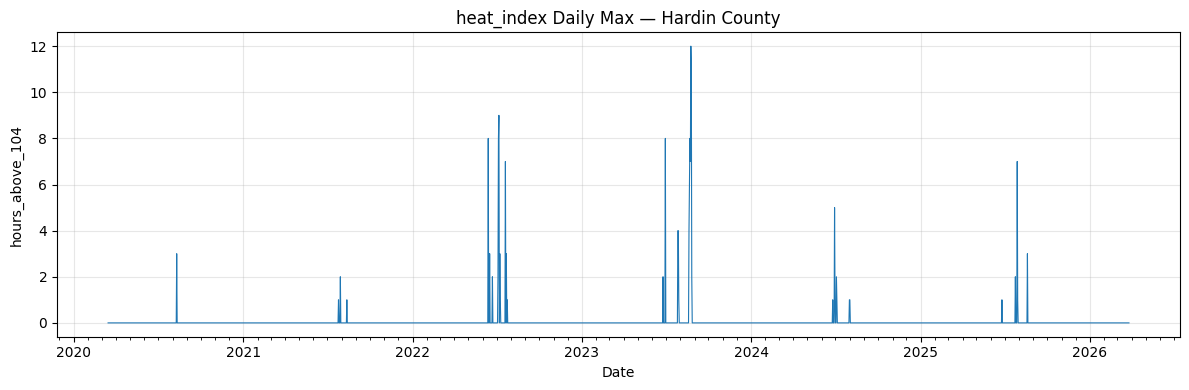

In [50]:
# ── Available daily_summary values for the daily DataFrame ───────────────
#   daily_mean          — average value across all hours of the day
#   daily_max           — highest hourly value of the day
#   daily_min           — lowest hourly value of the day
#   hours_above_{t}     — hours the metric exceeded threshold t
#                         (e.g. "hours_above_90", "hours_above_104" for heat_index;
#                          "hours_above_80", "hours_above_85" for wbgt)
#   hours_below_{t}     — hours the metric was below threshold t
#                         (e.g. "hours_below_0", "hours_below_32" for wind_chill)
#                         Only available if thresholds were defined for this metric.

# Choose a county (edit as desired)
EXAMPLE_COUNTY = "Hardin County"

plot_county_timeseries(
    demo_daily,
    county=EXAMPLE_COUNTY,
    daily_summary="hours_above_104",
    title=f"{demo_metric} Daily Max — {EXAMPLE_COUNTY}",
    date_range=("2020-03-15", "2026-03-26")
);

### 6b — Choropleth Map: Average Daily Max across Counties

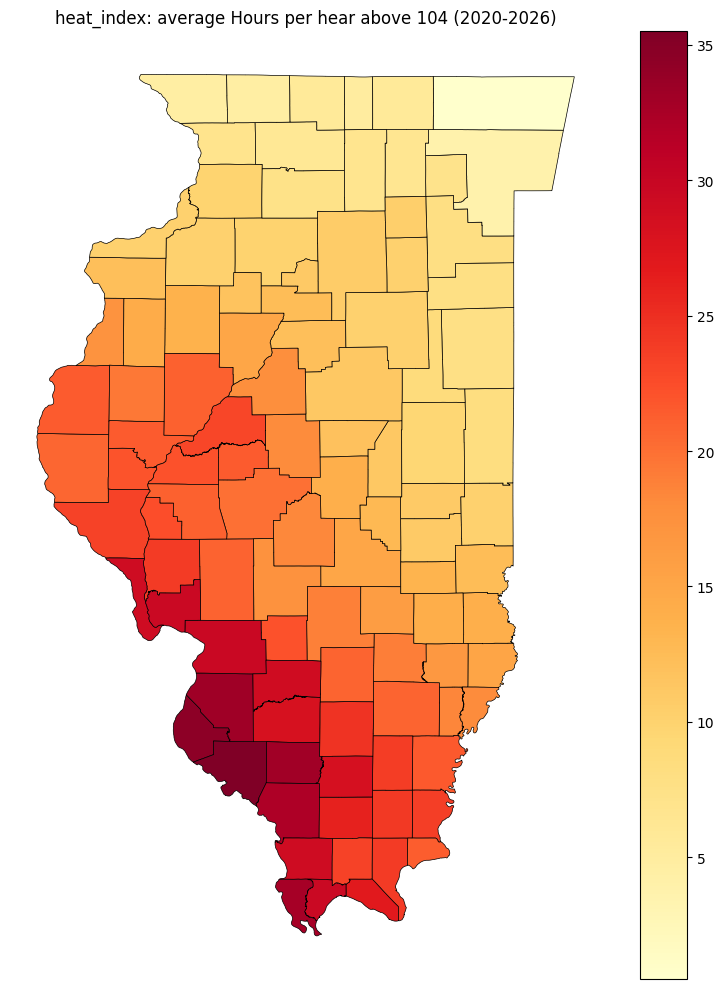

In [54]:
# ── Available average_summary values for the averages DataFrame ────────────
#   avg_daily_max                   — mean of daily maxima over the full period
#   avg_daily_mean                  — mean of daily means over the full period
#   avg_daily_min                   — mean of daily minima over the full period
#   avg_days_per_year_above_{t}     — average days/year exceeding threshold t
#   avg_hours_per_year_above_{t}    — average hours/year exceeding threshold t
#                                     (e.g. "avg_days_per_year_above_90" for heat_index)
#   avg_days_per_year_below_{t}     — average days/year below threshold t
#   avg_hours_per_year_below_{t}    — average hours/year below threshold t
#                                     (e.g. "avg_days_per_year_below_32" for wind_chill)

plot_county_map(
    demo_averages,
    average_summary="avg_hours_per_year_above_104",
    shapefile_path=SHAPEFILE_PATH,
    title=f"{demo_metric}: average Hours per hear above 104 ({YEAR_START}-{YEAR_END})",
);

### 6c — Threshold Heatmap: Exceedance Hours by County and Year

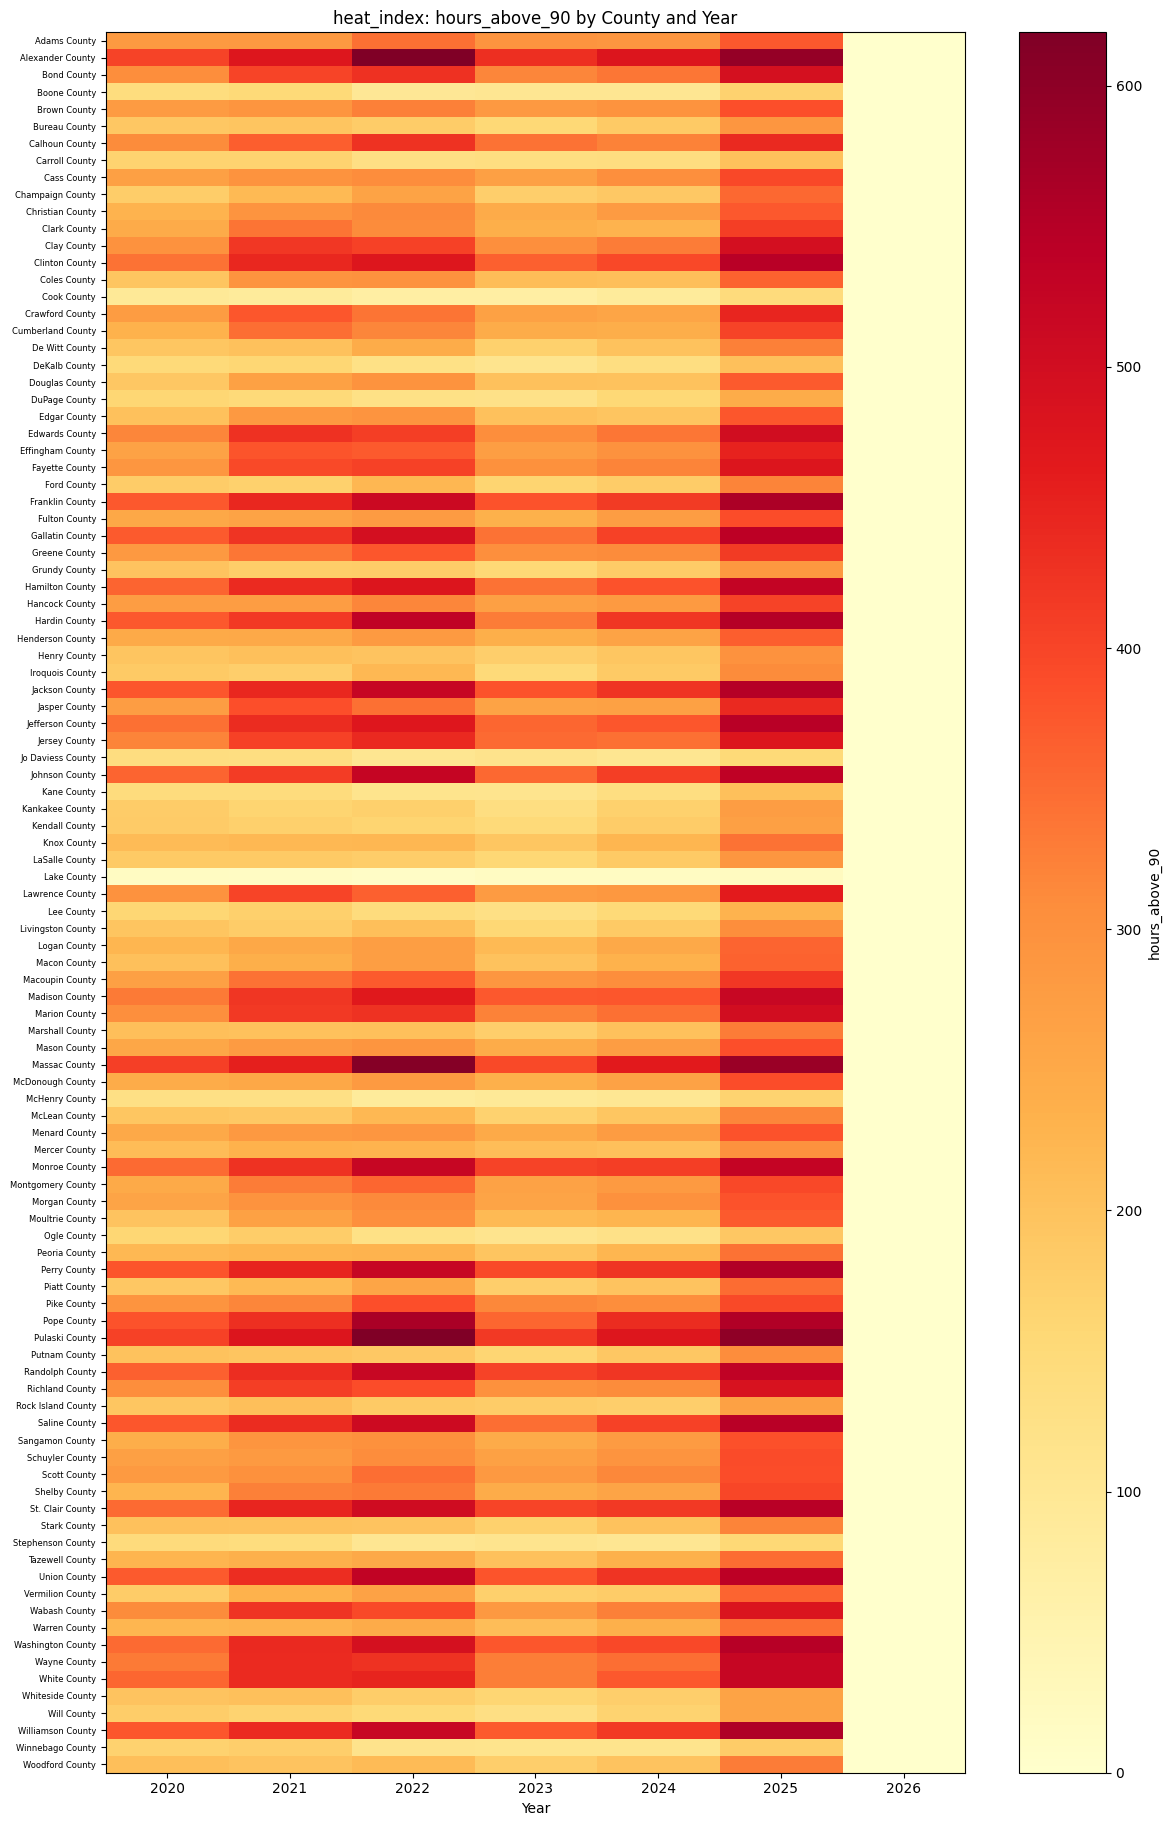

In [53]:
demo_above, demo_below = _get_thresholds(demo_metric)

if demo_above:
    t = demo_above[0]
    col = f"hours_above_{t}"
    plot_threshold_heatmap(
        demo_daily,
        metric_col=col,
        title=f"{demo_metric}: {col} by County and Year",
    )
elif demo_below:
    t = demo_below[0]
    col = f"hours_below_{t}"
    plot_threshold_heatmap(
        demo_daily,
        metric_col=col,
        title=f"{demo_metric}: {col} by County and Year",
    )
else:
    print(f"No thresholds defined for {demo_metric} — skipping heatmap.")